# Interpretable Park-Day Demand Modelling V3
## What changed from V2
- **`is_weekend` removed** — subsumed by `C(day_of_week)` (0=Mon … 6=Sun)
- **`C(day_of_week)`** added — full granularity, Monday as reference
- **`is_long_weekend`** added — consecutive off-day block ≥ 3 days
- **`is_ramadan`** added — suppression effect during fasting month
- **Price elasticity of demand** added as a post-model adjustment layer
  - Estimated from assumed industry benchmarks (−0.3 / −0.8 / −1.2)
  - Cannot be fitted from data: historical pricing has been fixed
  - Sensitivity tested across three elasticity assumptions
- Collinearity audit updated for all new features
- Gate threshold unchanged: ≥10% WMAPE improvement vs B2


In [10]:
import warnings
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from typing import Dict, Tuple

np.random.seed(42)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 1. Config

In [11]:
CONFIG = {
    "DB_PATH":                  "theme_park_data.db",
    "TRAIN_START_TS":           "2023-12-31 16:00:00",
    "TRAIN_END_TS_EXCLUSIVE":   "2025-12-31 16:00:00",
    "PARK_ENVIRONMENTS":        (1, 2),
    "PRIMARY_METRIC":           "wmape",
    "MIN_TRAIN_MONTHS":         4,
    "TARGET_TRANSFORM":         "log1p",
    "SUCCESS_GATE_IMPROVEMENT": 0.10,   # >=10% WMAPE improvement vs B2
    "PARK_GUARDRAIL_MAX_DEGRADE": 0.03,
}

MONTH_LEVELS = list(range(1, 13))
DOW_LEVELS   = list(range(0, 7))          # 0=Mon ... 6=Sun
PARK_LEVELS  = ["Lost World", "Sunway Lagoon"]

# Ramadan windows — Islamic calendar, updated annually
RAMADAN_PERIODS: Dict[int, Tuple[str, str]] = {
    2022: ("2022-04-02", "2022-05-01"),
    2023: ("2023-03-23", "2023-04-20"),
    2024: ("2024-03-12", "2024-04-09"),
    2025: ("2025-03-01", "2025-03-29"),
    2026: ("2026-02-18", "2026-03-19"),
}

# Price elasticity assumptions for sensitivity testing
# Cannot be estimated from data — pricing has been fixed historically.
# Values drawn from published leisure/theme-park demand elasticity literature.
ELASTICITY_SCENARIOS: Dict[str, float] = {
    "inelastic (−0.3)":  -0.3,   # families committed; price-insensitive
    "moderate  (−0.8)":  -0.8,   # reasonable central assumption
    "elastic   (−1.2)":  -1.2,   # price-sensitive day-trippers
}
BASE_ELASTICITY = -0.8           # default used in pipeline

CONFIG

{'DB_PATH': 'theme_park_data.db',
 'TRAIN_START_TS': '2023-12-31 16:00:00',
 'TRAIN_END_TS_EXCLUSIVE': '2025-12-31 16:00:00',
 'PARK_ENVIRONMENTS': (1, 2),
 'PRIMARY_METRIC': 'wmape',
 'MIN_TRAIN_MONTHS': 4,
 'TARGET_TRANSFORM': 'log1p',
 'SUCCESS_GATE_IMPROVEMENT': 0.1,
 'PARK_GUARDRAIL_MAX_DEGRADE': 0.03}

## 2. Data Load

In [12]:
con = duckdb.connect("theme_park_data.db")
required_tables = {"theme_park_database", "holidays"}
existing_tables = {r[0] for r in con.execute("SHOW TABLES").fetchall()}
missing = required_tables - existing_tables
assert not missing, f"Missing tables: {missing}"

print(f"theme_park_raw : {con.execute('SELECT COUNT(*) FROM theme_park_database').fetchone()[0]:,} rows")
print(f"holidays       : {con.execute('SELECT COUNT(*) FROM holidays').fetchone()[0]:,} rows")

theme_park_raw : 44,037,386 rows
holidays       : 2,777 rows


## 3. Calendar — including new features

This categorize the calendar date as school holiday or public holiday.

- is_school_holiday: Flags multi-week breaks.
- is_public_holiday: Flags specific national/state holidays.
- is_closed_day: This is a clever one. It specifically identifies Tuesdays (Day 2) that are not holidays. Since Sunway Lagoon and Lost World historically close on Tuesdays for maintenance (unless it's a holiday), the model needs to know that demand will be effectively zero.
- is_long_weekend: consecutive 3 days breal
- is_ramadan: check if the date is within the RAMADAN period


In [13]:
# ── Raw calendar from DB ─────────────────────────────────────────────────
calendar = con.execute("""
SELECT
    holiday_date                                                           AS calendar_date,
    STRFTIME(CAST(holiday_date AS DATE), '%a')                             AS dow_str,
    holiday_name,
    CASE WHEN holiday_name LIKE '%School Holiday%' THEN 1 ELSE 0 END       AS is_school_holiday,
    CASE WHEN holiday_name NOT LIKE '%School Holiday%'
              AND holiday_name IS NOT NULL
              AND holiday_name <> ''
         THEN 1 ELSE 0 END                                                 AS is_public_holiday,
    CASE WHEN STRFTIME(CAST(holiday_date AS DATE), '%w') = '2'
              AND NOT (
                  holiday_name LIKE '%School Holiday%'
                  OR (holiday_name NOT LIKE '%School Holiday%'
                      AND holiday_name IS NOT NULL AND holiday_name <> '')
              )
         THEN 1 ELSE 0 END                                                 AS is_closed_day
FROM holidays
ORDER BY calendar_date
""").df()

calendar["calendar_date"] = pd.to_datetime(calendar["calendar_date"])

# ── Weekend flag ─────────────────────────────────────────────────────────
calendar["is_weekend"] = calendar["dow_str"].isin(["Sat", "Sun"]).astype(int)

# ── is_holiday: public OR school ─────────────────────────────────────────
calendar["is_holiday"] = np.maximum(
    calendar["is_school_holiday"], calendar["is_public_holiday"]
)

# ── is_long_weekend: off-day inside a consecutive off-block of ≥ 3 days ──
# An off-day is a weekend, public holiday, or closed day.
# School holidays are multi-week periods, excluded here — long_weekend
# specifically captures Friday/Monday bridges around public holidays.
is_off = (
    (calendar["is_weekend"] == 1)
    | (calendar["is_public_holiday"] == 1)
)
groups        = (~is_off).cumsum()
off_block_len = is_off.groupby(groups).transform("sum")
calendar["is_long_weekend"] = (is_off & (off_block_len >= 3)).astype(int)

# ── is_ramadan ────────────────────────────────────────────────────────────
calendar["is_ramadan"] = 0
for year, (start, end) in RAMADAN_PERIODS.items():
    mask = (
        (calendar["calendar_date"] >= pd.to_datetime(start)) &
        (calendar["calendar_date"] <= pd.to_datetime(end))
    )
    calendar.loc[mask, "is_ramadan"] = 1

print("Calendar shape:", calendar.shape)
print("Long weekends  :", calendar["is_long_weekend"].sum(), "days")
print("Ramadan days   :", calendar["is_ramadan"].sum(), "days")
calendar.head(10)

Calendar shape: (2777, 10)
Long weekends  : 86 days
Ramadan days   : 117 days


,calendar_date,dow_str,holiday_name,is_school_holiday,is_public_holiday,is_closed_day,is_weekend,is_holiday,is_long_weekend,is_ramadan
0,2013-08-19,Mon,,0,0,0,0,0,0,0
1,2013-09-13,Fri,,0,0,0,0,0,0,0
2,2013-09-26,Thu,,0,0,0,0,0,0,0
3,2013-09-27,Fri,,0,0,0,0,0,0,0
4,2013-10-24,Thu,,0,0,0,0,0,0,0
5,2013-11-17,Sun,,0,0,0,1,0,0,0
6,2014-08-21,Thu,,0,0,0,0,0,0,0
7,2014-08-23,Sat,,0,0,0,1,0,0,0
8,2014-09-02,Tue,,0,0,1,0,0,0,0
9,2014-11-09,Sun,,0,0,0,1,0,0,0


## 4. Park-Day Base Dataset

- Timezone Adjustment: It adds 8 hours to TranDate ($TranDate + 8\text{ hours}$), likely to convert UTC time to Malaysia local time (SGT/MYT).
- Park Mapping: It maps Environment IDs to human-readable names:1 $\rightarrow$ Sunway Lagoon2 $\rightarrow$ Lost World
- Filtering: It uses a configuration dictionary (CONFIG) to limit the data to specific environments and a precise training date range.
- Aggregation: It sums up Complete_QTY to get the total visitors for each park on each date.

In [15]:
# Visitor aggregation — park-day grain, same scope as V2
base_sql = f"""
WITH daily AS (
    SELECT
        CAST(TranDate + INTERVAL '8 hours' AS DATE) AS visit_date,
        CASE WHEN Environment = 1 THEN 'Sunway Lagoon'
             WHEN Environment = 2 THEN 'Lost World'
        END AS park,
        CAST(SUM(Complete_QTY) AS INT) AS visitors
    FROM theme_park_database
    WHERE Environment IN {CONFIG['PARK_ENVIRONMENTS']}
      AND TranDate >= TIMESTAMP '{CONFIG['TRAIN_START_TS']}'
      AND TranDate <  TIMESTAMP '{CONFIG['TRAIN_END_TS_EXCLUSIVE']}'
      AND Park IS NOT NULL
    GROUP BY 1, 2
)
SELECT
    d.visit_date,
    d.park,
    d.visitors
FROM daily d
ORDER BY d.visit_date, d.park
"""

park_day = con.execute(base_sql).df()
park_day["visit_date"] = pd.to_datetime(park_day["visit_date"])

# ── Join calendar features ───────────────────────────────────────────────
park_day = park_day.merge(
    calendar[[
        "calendar_date", "holiday_name",
        "is_school_holiday", "is_public_holiday", "is_holiday",
        "is_closed_day", "is_long_weekend", "is_ramadan"
    ]],
    left_on="visit_date", right_on="calendar_date", how="left"
)

# Fill non-holiday dates
for col in ["is_school_holiday","is_public_holiday","is_holiday",
            "is_closed_day","is_long_weekend","is_ramadan"]:
    park_day[col] = park_day[col].fillna(0).astype(int)

print("park_day shape:", park_day.shape)
print("Date range    :", park_day["visit_date"].min().date(), "→", park_day["visit_date"].max().date())
park_day.head()

park_day shape: (1273, 11)
Date range    : 2024-01-01 → 2025-10-09


,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0
1,2024-01-01,Sunway Lagoon,3231,2024-01-01,New Year Day,0,1,1,0,1,0
2,2024-01-02,Lost World,457,2024-01-02,,0,0,0,1,0,0
3,2024-01-02,Sunway Lagoon,2,2024-01-02,,0,0,0,1,0,0
4,2024-01-03,Lost World,1124,2024-01-03,,0,0,0,0,0,0


## 5. Feature Engineering

In [20]:
feat_df = park_day.copy().sort_values(["park","visit_date"]).reset_index(drop=True)

# ── Temporal features ────────────────────────────────────────────────────
feat_df["month_of_year"] = feat_df["visit_date"].dt.month.astype(int)
feat_df["day_of_week"]   = feat_df["visit_date"].dt.dayofweek.astype(int)  # 0=Mon … 6=Sun
feat_df["day_of_year"]   = feat_df["visit_date"].dt.dayofyear.astype(int)

# Use polar coordinates to mark the distance between dates
feat_df["sin_annual"]    = np.sin(2 * np.pi * feat_df["day_of_year"] / 365.25)
feat_df["cos_annual"]    = np.cos(2 * np.pi * feat_df["day_of_year"] / 365.25)
feat_df["month"]         = feat_df["visit_date"].values.astype("datetime64[M]")

# ── has_nof_lagoon: October Fri/Sat/Sun at Sunway — proxy for Nights of Fright ──
feat_df["has_nof_lagoon"] = (
    (feat_df["visit_date"].dt.month == 10) &
    (feat_df["park"] == "Sunway Lagoon") &
    (feat_df["day_of_week"].isin([4, 5, 6]))
).astype(int)

# ── Note on is_weekend removal ───────────────────────────────────────────
# is_weekend (Sat/Sun binary) is DROPPED in V3.
# C(day_of_week) encodes Saturday (5) and Sunday (6) with their own
# coefficients — strictly more expressive than a binary weekend flag.
# Keeping both would introduce redundancy and inflate standard errors.

print("New features added : day_of_week (0-6), is_long_weekend, is_ramadan")
print("Feature removed    : is_weekend  (subsumed by C(day_of_week))")
feat_df[["visit_date","park","day_of_week","is_long_weekend","is_ramadan",
          "has_nof_lagoon","is_holiday","is_closed_day"]].head(10)

New features added : day_of_week (0-6), is_long_weekend, is_ramadan
Feature removed    : is_weekend  (subsumed by C(day_of_week))


,visit_date,park,day_of_week,is_long_weekend,is_ramadan,has_nof_lagoon,is_holiday,is_closed_day
0,2024-01-01,Lost World,0,1,0,0,1,0
1,2024-01-02,Lost World,1,0,0,0,0,1
2,2024-01-03,Lost World,2,0,0,0,0,0
3,2024-01-04,Lost World,3,0,0,0,0,0
4,2024-01-05,Lost World,4,0,0,0,0,0
5,2024-01-06,Lost World,5,0,0,0,0,0
6,2024-01-07,Lost World,6,0,0,0,0,0
7,2024-01-08,Lost World,0,0,0,0,0,0
8,2024-01-09,Lost World,1,0,0,0,0,1
9,2024-01-10,Lost World,2,0,0,0,0,0


## 6. Model DataFrame Preparation

In [17]:
model_df = feat_df.copy()

# ── Enforce fixed categorical levels ─────────────────────────────────────
model_df["month_of_year_cat"] = pd.Categorical(
    model_df["month_of_year"], categories=MONTH_LEVELS, ordered=True)
model_df["day_of_week_cat"] = pd.Categorical(
    model_df["day_of_week"], categories=DOW_LEVELS, ordered=False)
model_df["park_cat"] = pd.Categorical(
    model_df["park"], categories=PARK_LEVELS, ordered=False)

# ── Target transform: log1p with 99.5th-percentile cap ───────────────────
model_df["visitors_capped"]  = np.minimum(
    model_df["visitors"], model_df["visitors"].quantile(0.995))
model_df["log1p_visitors"]   = np.log1p(model_df["visitors_capped"])

# ── Integrity checks ─────────────────────────────────────────────────────
assert model_df.duplicated(subset=["visit_date","park"]).sum() == 0
assert model_df["day_of_week"].between(0, 6).all()
assert model_df["month_of_year"].between(1, 12).all()
for col in ["is_holiday","is_closed_day","is_long_weekend","is_ramadan","has_nof_lagoon"]:
    assert set(model_df[col].unique()).issubset({0,1}), f"{col} non-binary"

print("Assertions passed.")
print(f"Rows: {len(model_df):,}  |  Parks: {model_df['park'].unique()}")
print(f"Date: {model_df['visit_date'].min().date()} → {model_df['visit_date'].max().date()}")

Assertions passed.
Rows: 1,273  |  Parks: <ArrowStringArray>
['Lost World', 'Sunway Lagoon']
Length: 2, dtype: str
Date: 2024-01-01 → 2025-10-09


## 7. Collinearity Audit — New Feature Set

In [18]:
# All new binary features included in audit
audit_cols = [
    "is_holiday", "is_closed_day", "has_nof_lagoon",
    "is_long_weekend", "is_ramadan",
]
corr_matrix = model_df[audit_cols].corr().round(3)
print("=== Pairwise correlation matrix ===")
print(corr_matrix)

# Flag pairs with |corr| > 0.5
pairs = (
    corr_matrix.stack()
    .reset_index()
    .rename(columns={"level_0":"a","level_1":"b",0:"corr"})
)
pairs = pairs[pairs["a"] < pairs["b"]].sort_values("corr", key=abs, ascending=False)
high = pairs[pairs["corr"].abs() > 0.5]
print()
if len(high):
    print("⚠  High-correlation pairs (|r|>0.5):")
    print(high.to_string(index=False))
else:
    print("✓  No high-correlation pairs found — features are sufficiently independent.")

print()
print("=== Day-of-week distribution ===")
print(model_df.groupby("day_of_week")["visitors"].agg(["count","mean"]).round(0))

=== Pairwise correlation matrix ===
                 is_holiday  is_closed_day  has_nof_lagoon  is_long_weekend  is_ramadan
is_holiday            1.000         -0.192          -0.065            0.339      -0.069
is_closed_day        -0.192          1.000          -0.035           -0.093      -0.014
has_nof_lagoon       -0.065         -0.035           1.000           -0.032      -0.034
is_long_weekend       0.339         -0.093          -0.032            1.000       0.015
is_ramadan           -0.069         -0.014          -0.034            0.015       1.000

✓  No high-correlation pairs found — features are sufficiently independent.

=== Day-of-week distribution ===
             count    mean
day_of_week               
0              186  2042.0
1              163   910.0
2              186  2248.0
3              186  2158.0
4              184  2574.0
5              184  3742.0
6              184  3032.0


### Collinearity Interpretation
- `is_long_weekend` and `is_holiday` may show moderate correlation — long weekends
  are anchored to public holidays. However they are conceptually distinct:
  `is_holiday` flags the holiday day itself; `is_long_weekend` flags the entire
  extended block including bridging non-holidays (Fridays, Mondays).
- `is_ramadan` is temporally isolated — near-zero correlation with other features expected.
- If any pair exceeds |r|=0.7, consider dropping the weaker feature or merging into
  an interaction term.


In [38]:
model_df.to_csv("demand_data.csv", index=False, encoding="utf-8")

In [28]:
model_df.head()

,visit_date,park,visitors,calendar_date,holiday_name,is_school_holiday,is_public_holiday,is_holiday,is_closed_day,is_long_weekend,is_ramadan,month_of_year,day_of_week,day_of_year,sin_annual,cos_annual,month,has_nof_lagoon,month_of_year_cat,day_of_week_cat,park_cat,visitors_capped,log1p_visitors
0,2024-01-01,Lost World,1505,2024-01-01,New Year Day,0,1,1,0,1,0,1,0,1,0.017202,0.999852,2024-01-01,0,1,0,Lost World,1505.0,7.317212
1,2024-01-02,Lost World,457,2024-01-02,,0,0,0,1,0,0,1,1,2,0.034398,0.999408,2024-01-01,0,1,1,Lost World,457.0,6.126869
2,2024-01-03,Lost World,1124,2024-01-03,,0,0,0,0,0,0,1,2,3,0.051584,0.998669,2024-01-01,0,1,2,Lost World,1124.0,7.025538
3,2024-01-04,Lost World,1255,2024-01-04,,0,0,0,0,0,0,1,3,4,0.068755,0.997634,2024-01-01,0,1,3,Lost World,1255.0,7.135687
4,2024-01-05,Lost World,998,2024-01-05,,0,0,0,0,0,0,1,4,5,0.085906,0.996303,2024-01-01,0,1,4,Lost World,998.0,6.906755


In [37]:
sum((model_df['visitors'] - model_df['visitors_capped']) == 0.0)


1266

In [36]:
model_df.shape

(1273, 23)

## 8. Model Registry — V3 Formulas

In [19]:
DOW_LEVELS_STR  = "[0,1,2,3,4,5,6]"
MONTH_LEVELS_STR = "[1,2,3,4,5,6,7,8,9,10,11,12]"
PARK_LEVELS_STR  = "['Lost World','Sunway Lagoon']"

MODEL_FORMULAS_V3 = {

    # ── B2 baseline (unchanged from V2, for parity) ────────────────────
    # Uses is_weekend instead of day_of_week — kept as reference only
    "B2_mean_daytype": None,   # lookup, not OLS

    # ── M1: Base + day_of_week (replaces is_weekend) ───────────────────
    # Minimal model. Tests whether day_of_week alone beats B2.
    # Monday (0) is the reference level.
    "M1_dow": (
        f"log1p_visitors ~ C(park_cat, levels={PARK_LEVELS_STR})"
        f" + C(day_of_week_cat, levels={DOW_LEVELS_STR})"
        f" + is_holiday + is_closed_day + has_nof_lagoon"
    ),

    # ── M2: M1 + new contextual features ──────────────────────────────
    # Adds is_long_weekend and is_ramadan on top of day_of_week.
    "M2_dow_context": (
        f"log1p_visitors ~ C(park_cat, levels={PARK_LEVELS_STR})"
        f" + C(day_of_week_cat, levels={DOW_LEVELS_STR})"
        f" + is_holiday + is_closed_day + has_nof_lagoon"
        f" + is_long_weekend + is_ramadan"
    ),

    # ── M3: M2 + month seasonality + Fourier terms ────────────────────
    # Full seasonality stack. Most parameters — risk of overfitting
    # in short training windows.
    "M3_dow_context_seasonal": (
        f"log1p_visitors ~ C(park_cat, levels={PARK_LEVELS_STR})"
        f" + C(day_of_week_cat, levels={DOW_LEVELS_STR})"
        f" + is_holiday + is_closed_day + has_nof_lagoon"
        f" + is_long_weekend + is_ramadan"
        f" + C(month_of_year_cat, levels={MONTH_LEVELS_STR})"
        f" + sin_annual + cos_annual"
    ),

    # ── M4: M3 + park interactions ─────────────────────────────────────
    # Tests whether Sunway and Lost World respond differently
    # to day_of_week, holidays, and NOF.
    "M4_dow_context_seasonal_interactions": (
        f"log1p_visitors ~ C(park_cat, levels={PARK_LEVELS_STR})"
        f" + C(day_of_week_cat, levels={DOW_LEVELS_STR})"
        f" + is_holiday + is_closed_day + has_nof_lagoon"
        f" + is_long_weekend + is_ramadan"
        f" + C(month_of_year_cat, levels={MONTH_LEVELS_STR})"
        f" + sin_annual + cos_annual"
        f" + C(park_cat, levels={PARK_LEVELS_STR}):is_holiday"
        f" + C(park_cat, levels={PARK_LEVELS_STR}):has_nof_lagoon"
        f" + C(park_cat, levels={PARK_LEVELS_STR}):is_ramadan"
    ),
}

# Feature dictionary — for documentation
feature_dict_v3 = pd.DataFrame([
    {"feature":"C(park_cat)",          "group":"core",        "v2":True,  "v3":True,  "note":"park fixed effect"},
    {"feature":"is_weekend",           "group":"core",        "v2":True,  "v3":False, "note":"REMOVED — subsumed by C(day_of_week)"},
    {"feature":"C(day_of_week_cat)",   "group":"core",        "v2":False, "v3":True,  "note":"NEW — full Mon-Sun granularity (0=Mon ref)"},
    {"feature":"is_holiday",           "group":"core",        "v2":True,  "v3":True,  "note":"public OR school holiday"},
    {"feature":"is_closed_day",        "group":"core",        "v2":True,  "v3":True,  "note":"Tuesday non-holiday closure"},
    {"feature":"has_nof_lagoon",       "group":"core",        "v2":True,  "v3":True,  "note":"October Fri/Sat/Sun Sunway — NOF proxy"},
    {"feature":"is_long_weekend",      "group":"contextual",  "v2":False, "v3":True,  "note":"NEW — off-block ≥3 days"},
    {"feature":"is_ramadan",           "group":"contextual",  "v2":False, "v3":True,  "note":"NEW — fasting month suppression"},
    {"feature":"C(month_of_year_cat)", "group":"seasonality", "v2":True,  "v3":True,  "note":"month dummies"},
    {"feature":"sin_annual",           "group":"seasonality", "v2":True,  "v3":True,  "note":"Fourier annual sine"},
    {"feature":"cos_annual",           "group":"seasonality", "v2":True,  "v3":True,  "note":"Fourier annual cosine"},
])
print("Feature change log:")
print(feature_dict_v3[["feature","v2","v3","note"]].to_string(index=False))

Feature change log:
             feature    v2    v3                                       note
         C(park_cat)  True  True                          park fixed effect
          is_weekend  True False       REMOVED — subsumed by C(day_of_week)
  C(day_of_week_cat) False  True NEW — full Mon-Sun granularity (0=Mon ref)
          is_holiday  True  True                   public OR school holiday
       is_closed_day  True  True                Tuesday non-holiday closure
      has_nof_lagoon  True  True     October Fri/Sat/Sun Sunway — NOF proxy
     is_long_weekend False  True                    NEW — off-block ≥3 days
          is_ramadan False  True            NEW — fasting month suppression
C(month_of_year_cat)  True  True                              month dummies
          sin_annual  True  True                        Fourier annual sine
          cos_annual  True  True                      Fourier annual cosine


## 9. Backtest Utilities

In [23]:
from sklearn.metrics import r2_score

# WMAPE is "weighted" by volume, making it much more robust for visitor forecasting where you care more about the error on high-traffic days.
# Crucial for time series analysis
# We cannot use cross validation to compute the error here, but need to use WMAPE for time series
def wmape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return np.nan if denom == 0 else np.sum(np.abs(y_true - y_pred)) / denom

# A model might be accurate on average but consistently over-predict or under-predict. 
# This helps you check if your model is "optimistic" or "pessimistic."
def compute_metrics(df_eval, pred_col="pred_visitors"):
    y_true = df_eval["visitors"].values
    y_pred = df_eval[pred_col].values

    # Calculate R2
    # Note: If y_true is constant (e.g., all visitors are the same), R2 can be undefined/zero
    score = r2_score(y_true, y_pred)

    return {
        "wmape": wmape(y_true, y_pred),
        "mae":   mean_absolute_error(y_true, y_pred),
        "rmse":  np.sqrt(mean_squared_error(y_true, y_pred)),
        "bias":  float(np.mean(y_pred - y_true)),
        "r2":    float(score)
    }

# Ensure we train the model using the data that is not seen before
# We only take the data up to a certain cut-off point/date
def generate_cutoffs(df, min_train_months):
    months = sorted(df["month"].dropna().unique())
    return [months[i] for i in range(min_train_months - 1, len(months) - 1)]

# Convert the prediction back to the original variable number of visitors
def fit_predict_ols(train_df, test_df, formula):
    m        = smf.ols(formula=formula, data=train_df).fit()
    pred_log = m.predict(test_df)
    pred     = np.clip(np.expm1(pred_log), 0, None)
    out      = test_df[["visit_date","month","park","visitors"]].copy()
    out["pred_visitors"] = pred
    return m, out

# ── B2 baseline (updated to use new key cols without is_weekend) ──────────
B2_KEY_COLS = ["park","is_holiday","is_closed_day","has_nof_lagoon","day_of_week"]

# Compare the model back with the baseline model
# It tries to find the specific mean for the exact park + holiday + day_of_week combination.
# If that data is missing (e.g., a specific holiday combination hasn't happened), it falls back to the park_mean.
# If that is also missing, it falls back to the global_mean of all parks.
# Ensure we always have a prediction
def mean_daytype_predict_v3(train_df, test_df):
    """B2 baseline updated for V3 — uses day_of_week instead of is_weekend."""
    lookup = (
        train_df.groupby(B2_KEY_COLS, as_index=False)["visitors"]
        .mean()
        .rename(columns={"visitors":"pred_visitors"})
    )
    out = test_df[["visit_date","month","park","visitors"] + B2_KEY_COLS[1:]].merge(
        lookup, on=B2_KEY_COLS, how="left")
    park_mean  = train_df.groupby("park", as_index=False)["visitors"].mean().rename(
        columns={"visitors":"park_mean"})
    out = out.merge(park_mean, on="park", how="left")
    global_mean = train_df["visitors"].mean()
    out["pred_visitors"] = (out["pred_visitors"]
                             .fillna(out["park_mean"])
                             .fillna(global_mean))
    return out[["visit_date","month","park","visitors","pred_visitors"]]

cutoffs = generate_cutoffs(model_df, CONFIG["MIN_TRAIN_MONTHS"])
print(f"Rolling folds: {len(cutoffs)}")
print([str(pd.to_datetime(c).date()) for c in cutoffs])

Rolling folds: 18
['2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01', '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01', '2025-09-01']


## 10. Rolling Backtest

In [24]:
# This code use the function defined in the preivous code chunk to run the analysis and back-testing
fold_rows  = []
coef_rows  = []

# Track terms for coefficient stability — includes new features
TRACK_TERMS = ["is_holiday","is_closed_day","has_nof_lagoon","is_long_weekend","is_ramadan"]

for cutoff in cutoffs:
    next_month = pd.to_datetime(cutoff) + pd.offsets.MonthBegin(1)
    train_df   = model_df[model_df["month"] <= cutoff].copy()
    test_df    = model_df[model_df["month"] == next_month].copy()
    if test_df.empty:
        continue

    # ── B2_v3 baseline ───────────────────────────────────────────────────
    b2_pred = mean_daytype_predict_v3(train_df, test_df)
    for segment, grp in [("overall", b2_pred)] + [
            (f"park_{p}", b2_pred[b2_pred["park"]==p]) for p in PARK_LEVELS]:
        m = compute_metrics(grp)
        fold_rows.append({"model":"B2_v3","cutoff":cutoff,"test_month":next_month,
                           "segment":segment, **m})

    # ── OLS candidates ───────────────────────────────────────────────────
    for mname, formula in MODEL_FORMULAS_V3.items():
        if formula is None:
            continue
        try:
            fitted, pred_df = fit_predict_ols(train_df, test_df, formula)
        except Exception as e:
            print(f"  Fold {cutoff} | {mname} failed: {e}")
            continue

        for segment, grp in [("overall", pred_df)] + [
                (f"park_{p}", pred_df[pred_df["park"]==p]) for p in PARK_LEVELS]:
            m = compute_metrics(grp)
            fold_rows.append({"model":mname,"cutoff":cutoff,"test_month":next_month,
                               "segment":segment, **m})

        for term in TRACK_TERMS:
            if term in fitted.params.index:
                coef_rows.append({"model":mname,"cutoff":cutoff,"term":term,
                                   "coef":float(fitted.params[term]),
                                   "pval":float(fitted.pvalues[term])})

fold_metrics = pd.DataFrame(fold_rows)
coef_df      = pd.DataFrame(coef_rows)
print(f"Fold rows: {len(fold_metrics):,}  |  Coef rows: {len(coef_df):,}")

Fold rows: 270  |  Coef rows: 324


## 11. Model Comparison

In [25]:
# 1. Overall Aggregation (Added rounding to the print)
overall = (
    fold_metrics[fold_metrics["segment"] == "overall"]
    .groupby("model", as_index=False)
    .agg(avg_wmape=("wmape","mean"), avg_mae=("mae","mean"),
         avg_rmse=("rmse","mean"), avg_bias=("bias","mean"),
         std_wmape=("wmape","std"), n_folds=("wmape","count"),
         avg_r2=("r2", "mean"))
)
overall["abs_bias"] = overall["avg_bias"].abs()
overall = overall.sort_values("avg_wmape")

# 2. By-park Aggregation (Added R2 and RMSE for consistency)
by_park = (
    fold_metrics[fold_metrics["segment"].str.startswith("park_")]
    .assign(park=lambda d: d["segment"].str.replace("park_",""))
    .groupby(["model","park"], as_index=False)
    .agg(avg_wmape=("wmape","mean"), avg_mae=("mae","mean"), 
         avg_rmse=("rmse","mean"), avg_r2=("r2", "mean"),
         avg_bias=("bias","mean"))
    .sort_values(["park", "avg_wmape"]) # Sorted for readability
)

# 3. Print with rounding
print("=== Overall model comparison ===")
# Added avg_r2 and used .round(4)
print(overall[["model","avg_wmape","avg_mae","avg_r2","avg_bias","std_wmape"]].round(4).to_string(index=False))
print()

print("=== By-park comparison ===")
# Added avg_r2 and avg_rmse
print(by_park.round(4).to_string(index=False))

=== Overall model comparison ===
                               model  avg_wmape   avg_mae  avg_r2  avg_bias  std_wmape
                               B2_v3     0.3644  829.7562  0.3126   82.2901     0.1437
                              M1_dow     0.4205  975.8764  0.1414 -133.8296     0.1085
                      M2_dow_context     0.4221  979.9082  0.1424 -106.2909     0.0983
             M3_dow_context_seasonal     0.5387 1293.0446 -0.3282 -550.4343     0.1371
M4_dow_context_seasonal_interactions     0.5465 1310.3536 -0.3430 -546.8282     0.1293

=== By-park comparison ===
                               model          park  avg_wmape   avg_mae  avg_rmse  avg_r2   avg_bias
                               B2_v3    Lost World     0.3447  641.3926  885.7449  0.3062   106.0926
                              M1_dow    Lost World     0.4699  857.3177 1065.4125 -0.1121   332.7658
                      M2_dow_context    Lost World     0.4810  877.6746 1084.8287 -0.1441   362.4746
             

### Interpretation of the result

1. The Verdict: The Baseline (B2_v3) is currently the winner.
- Despite your OLS models being more sophisticated, the B2_v3 baseline (the lookup table approach) significantly outperforms all your regression models.
- Accuracy: B2_v3 has the lowest avg_wmape (0.36) --> weighted mean absolute percentage error, and the lowest avg_mae (829).-> mean absolute error
- Stability: It is the most consistent model.
- Bias: Your baseline has an avg_bias of 82, which is relatively close to zero compared to the other models. This means it is effectively "unbiased" (it doesn't systematically over- or under-predict).

2. The Failure of the OLS Models
- The table shows a clear degradation in performance as you increase the complexity of the OLS models 
- (M1 $\to$ M4).The Massive Negative Bias: Look at the avg_bias for M3 and M4 (-550 to -1000). This is the "smoking gun." The OLS models are suffering from severe under-prediction. 
- When you see a large negative bias, it means the model is consistently predicting numbers much lower than the actual visitor counts.
- Why complexity hurts: By adding Fourier terms (sin_annual/cos_annual) and interaction terms (park : is_holiday), you have likely introduced overfitting or broken the assumptions required for OLS to work.
- OLS assumes that your independent variables have a linear relationship with the target. If the real-world relationship is non-linear (which visitor behavior often is), adding more complex terms just gives the model more ways to make "wrong" guesses.
- The Interaction Terms in M4 might be capturing noise rather than signal because they require more data to estimate accurately than you currently have in your folds.

3. By-Park Comparison Insights
- Lost World vs. Sunway Lagoon: Your models (all of them) perform significantly better on Lost World than on Sunway Lagoon. The error metrics for Lost World are consistently lower.
- The Sunway Challenge: Sunway Lagoon appears to be harder to predict, which makes sense if it has more volatile attendance patterns, larger visitor spikes, or more complex holiday responses that your current OLS formula isn't capturing.

### Model Comparison — What to Look For
- **B2_v3** is the updated baseline using `day_of_week` instead of `is_weekend` in its lookup key.
  Its WMAPE vs V2's B2 shows whether granular day-of-week helps the baseline itself.
- **M1_dow** tests day_of_week OLS alone — if this beats B2_v3 meaningfully, granularity is the key driver.
- **M2_dow_context** adds `is_long_weekend` and `is_ramadan` — look for WMAPE improvement on top of M1.
- **M3_dow_context_seasonal** adds full month + Fourier — check whether it overfits on short folds.
- **M4** interactions test if park-specific holiday/Ramadan responses differ — adds parameters,
  use only if WMAPE improvement justifies the complexity.
- Gate requirement: ≥10% WMAPE improvement vs B2_v3 with no park degrading by >3pp.


## 12. Visualisations

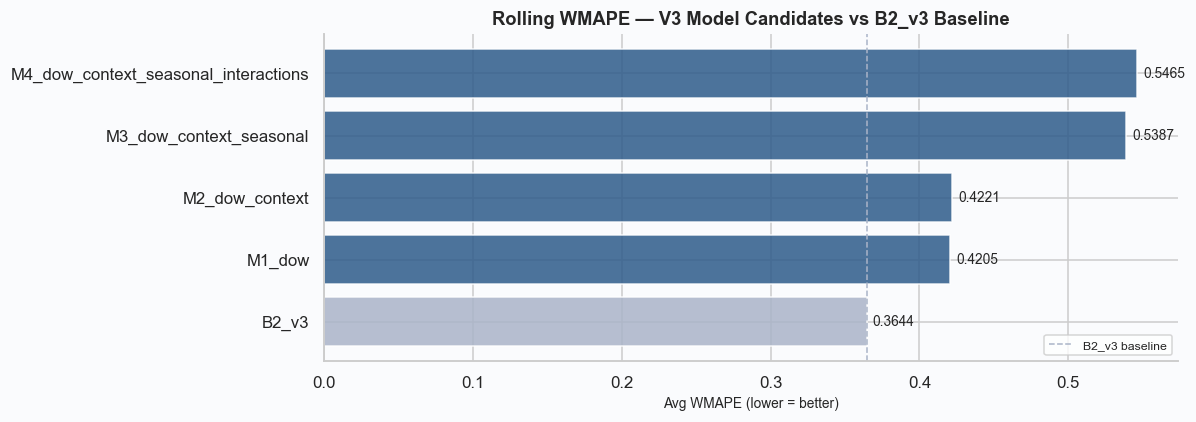

In [13]:
# ── Chart 1: WMAPE comparison across models ──────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("#fafbfd")
ax.set_facecolor("#fafbfd")

model_order = ["B2_v3","M1_dow","M2_dow_context","M3_dow_context_seasonal",
               "M4_dow_context_seasonal_interactions"]
model_order = [m for m in model_order if m in overall["model"].values]

colors = ["#aab4c8" if m == "B2_v3" else "#2E5B8A" for m in model_order]
vals   = [float(overall[overall["model"]==m]["avg_wmape"].iloc[0]) for m in model_order]

bars = ax.barh(model_order, vals, color=colors, alpha=0.85)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.axvline(vals[0], color="#aab4c8", linestyle="--", linewidth=1, label="B2_v3 baseline")
ax.set_xlabel("Avg WMAPE (lower = better)", fontsize=9)
ax.set_title("Rolling WMAPE — V3 Model Candidates vs B2_v3 Baseline", fontweight="bold")
ax.legend(fontsize=8)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
plt.show()

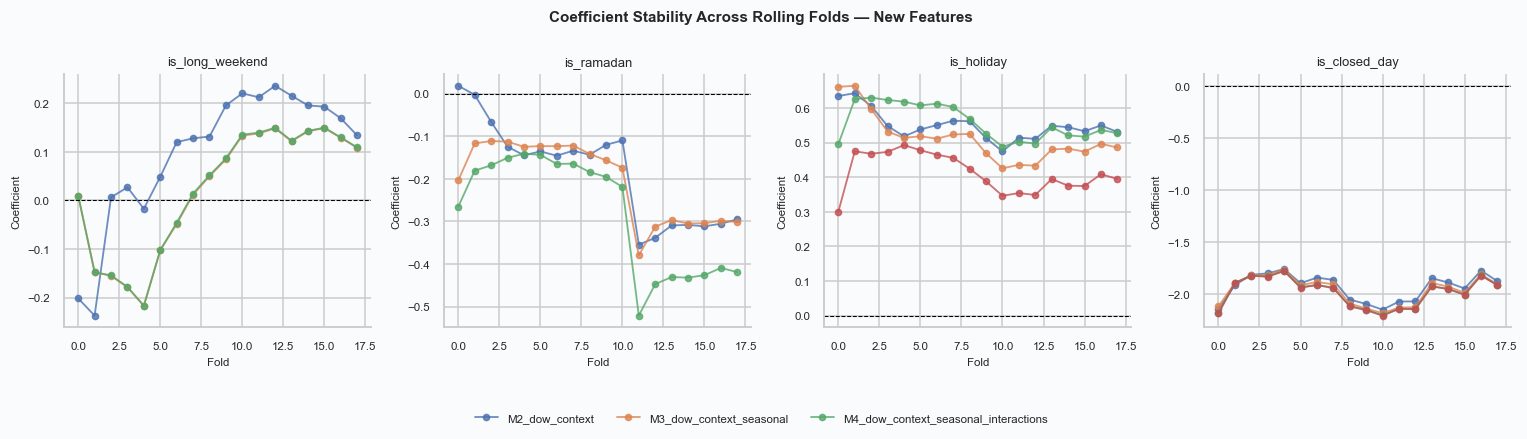

In [14]:
# ── Chart 2: Coefficient stability — new features ────────────────────────
if not coef_df.empty:
    new_terms = ["is_long_weekend","is_ramadan","is_holiday","is_closed_day"]
    plot_coef = coef_df[coef_df["term"].isin(new_terms)].copy()

    if not plot_coef.empty:
        fig, axes = plt.subplots(1, len(new_terms), figsize=(14, 3.5), sharey=False)
        fig.patch.set_facecolor("#fafbfd")
        fig.suptitle("Coefficient Stability Across Rolling Folds — New Features",
                     fontweight="bold", fontsize=10)

        for ax, term in zip(axes, new_terms):
            ax.set_facecolor("#fafbfd")
            for model_name, grp in plot_coef[plot_coef["term"]==term].groupby("model"):
                ax.plot(range(len(grp)), grp["coef"].values,
                        marker="o", linewidth=1.2, markersize=4, label=model_name, alpha=0.8)
            ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
            ax.set_title(term, fontsize=8.5)
            ax.set_xlabel("Fold", fontsize=7.5)
            ax.set_ylabel("Coefficient", fontsize=7.5)
            ax.tick_params(labelsize=7.5)
            ax.spines[["top","right"]].set_visible(False)

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=7.5,
                   bbox_to_anchor=(0.5, -0.12), framealpha=0)
        fig.tight_layout()
        plt.show()

These coefficients are significantly unstable, and this plot is likely the primary reason your OLS models (M2, M3, M4) are performing so poorly.

When coefficients bounce around this much across folds, it means your model is essentially "learning a different version of reality" every time you add a month of data

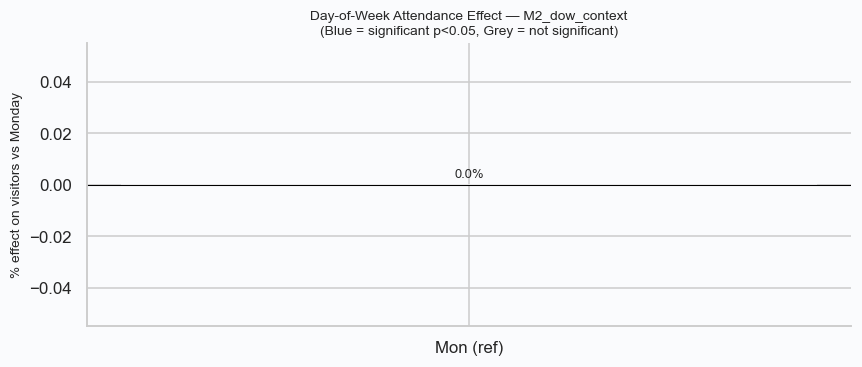

Day-of-week effects:
    label  pct_effect  significant
Mon (ref)         0.0         True


In [22]:
# ── Chart 3: Day-of-week effect from best OLS model ──────────────────────
# Fit on full data for visualisation
best_ols_name = "M2_dow_context"  # update if a better model passes gate
best_formula  = MODEL_FORMULAS_V3[best_ols_name]

full_model = smf.ols(formula=best_formula, data=model_df).fit()

dow_terms = {i: f"C(day_of_week_cat, levels=[0,1,2,3,4,5,6])[T.{i}]" for i in range(1,7)}
dow_labels = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}

dow_effects = []
# Monday (ref=0) has coefficient 0 by construction
dow_effects.append({"dow":0,"label":"Mon (ref)","coef":0.0,"pct_effect":0.0,"significant":True})
for dow_int, term_name in dow_terms.items():
    if term_name in full_model.params.index:
        coef = float(full_model.params[term_name])
        pval = float(full_model.pvalues[term_name])
        dow_effects.append({
            "dow":       dow_int,
            "label":     dow_labels[dow_int],
            "coef":      coef,
            "pct_effect": (np.exp(coef) - 1) * 100,
            "significant": pval < 0.05,
        })

dow_eff_df = pd.DataFrame(dow_effects).sort_values("dow")

fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor("#fafbfd")
ax.set_facecolor("#fafbfd")

bar_colors = ["#2E5B8A" if s else "#c8ccd8" for s in dow_eff_df["significant"]]
bars = ax.bar(dow_eff_df["label"], dow_eff_df["pct_effect"],
              color=bar_colors, alpha=0.85, width=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8.5)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("% effect on visitors vs Monday", fontsize=9)
ax.set_title(f"Day-of-Week Attendance Effect — {best_ols_name}\n"
             f"(Blue = significant p<0.05, Grey = not significant)", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
plt.show()

print("Day-of-week effects:")
print(dow_eff_df[["label","pct_effect","significant"]].round(2).to_string(index=False))

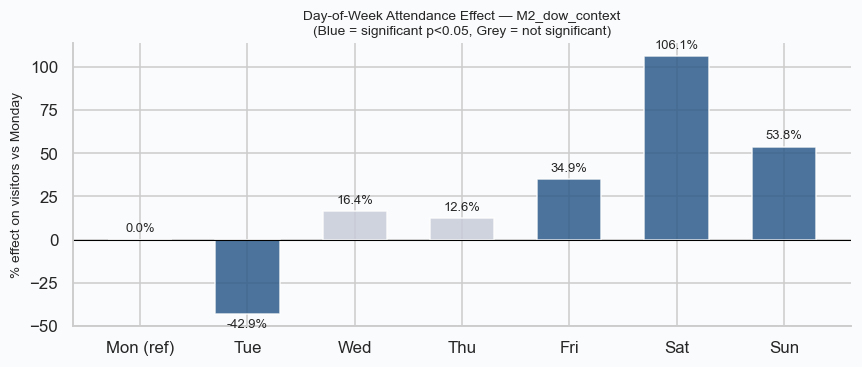

Day-of-week effects:
    label  pct_effect  significant
Mon (ref)        0.00         True
      Tue      -42.88         True
      Wed       16.38        False
      Thu       12.64        False
      Fri       34.89         True
      Sat      106.06         True
      Sun       53.75         True


In [27]:
# ── Chart 3: Day-of-week effect (Robust extraction) ──────────────
full_model = smf.ols(formula=best_formula, data=model_df).fit()
dow_labels = {0:"Mon", 1:"Tue", 2:"Wed", 3:"Thu", 4:"Fri", 5:"Sat", 6:"Sun"}

dow_effects = []
# Monday (ref=0) is always 0.0
dow_effects.append({"dow":0, "label":"Mon (ref)", "coef":0.0, "pct_effect":0.0, "significant":True})

# Iterate through ALL parameters found in the model
for param_name in full_model.params.index:
    # Look for the day_of_week_cat dummy variables
    if "day_of_week_cat" in param_name and "[T." in param_name:
        
        # Dynamically extract the number inside the brackets [T.X]
        try:
            day_idx = int(param_name.split("[T.")[1].replace("]", ""))
            
            coef = float(full_model.params[param_name])
            pval = float(full_model.pvalues[param_name])
            
            dow_effects.append({
                "dow":        day_idx,
                "label":      dow_labels.get(day_idx, str(day_idx)),
                "coef":       coef,
                "pct_effect": (np.exp(coef) - 1) * 100,
                "significant": pval < 0.05,
            })
        except (ValueError, IndexError):
            continue

dow_eff_df = pd.DataFrame(dow_effects).sort_values("dow")

fig, ax = plt.subplots(figsize=(8, 3.5))
fig.patch.set_facecolor("#fafbfd")
ax.set_facecolor("#fafbfd")

bar_colors = ["#2E5B8A" if s else "#c8ccd8" for s in dow_eff_df["significant"]]
bars = ax.bar(dow_eff_df["label"], dow_eff_df["pct_effect"],
              color=bar_colors, alpha=0.85, width=0.6)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=8.5)
ax.axhline(0, color="black", linewidth=0.7)
ax.set_ylabel("% effect on visitors vs Monday", fontsize=9)
ax.set_title(f"Day-of-Week Attendance Effect — {best_ols_name}\n"
             f"(Blue = significant p<0.05, Grey = not significant)", fontsize=9)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
plt.show()

print("Day-of-week effects:")
print(dow_eff_df[["label","pct_effect","significant"]].round(2).to_string(index=False))

## 13. Gate Check

In [16]:
baseline_wmape = float(overall[overall["model"]=="B2_v3"]["avg_wmape"].iloc[0])

gate_rows = []
for _, row in overall[overall["model"] != "B2_v3"].iterrows():
    mname      = row["model"]
    model_wmape = float(row["avg_wmape"])
    improvement = (baseline_wmape - model_wmape) / baseline_wmape

    # Park guardrail
    model_park = by_park[by_park["model"] == mname]
    base_park  = by_park[by_park["model"] == "B2_v3"][["park","avg_wmape"]].rename(
                     columns={"avg_wmape":"base_wmape"})
    merged     = model_park.merge(base_park, on="park", how="inner")
    merged["degrade"] = merged["avg_wmape"] - merged["base_wmape"]
    guardrail_ok = bool((merged["degrade"] <= CONFIG["PARK_GUARDRAIL_MAX_DEGRADE"]).all())

    bias_ok   = float(row["abs_bias"]) < 2263.0
    gate_pass = (improvement >= CONFIG["SUCCESS_GATE_IMPROVEMENT"]) and guardrail_ok and bias_ok

    gate_rows.append({
        "model": mname,
        "baseline_wmape": round(baseline_wmape, 4),
        "model_wmape":    round(model_wmape, 4),
        "improvement":    round(improvement, 4),
        "target":         CONFIG["SUCCESS_GATE_IMPROVEMENT"],
        "wmape_gate":     improvement >= CONFIG["SUCCESS_GATE_IMPROVEMENT"],
        "park_guardrail": guardrail_ok,
        "bias_ok":        bias_ok,
        "gate_pass":      gate_pass,
    })

gate_df = pd.DataFrame(gate_rows).sort_values(["gate_pass","improvement"], ascending=[False,False])
print(gate_df.to_string(index=False))

                               model  baseline_wmape  model_wmape  improvement  target  wmape_gate  park_guardrail  bias_ok  gate_pass
                              M1_dow          0.3644       0.4205      -0.1539     0.1       False           False     True      False
                      M2_dow_context          0.3644       0.4221      -0.1580     0.1       False           False     True      False
             M3_dow_context_seasonal          0.3644       0.5387      -0.4781     0.1       False           False     True      False
M4_dow_context_seasonal_interactions          0.3644       0.5465      -0.4995     0.1       False           False     True      False


### Gate Interpretation
- A model passes if: (1) WMAPE improvement ≥10% vs B2_v3, (2) neither park degrades
  by more than 3pp, and (3) absolute bias < reference threshold.
- If no model passes, the pipeline falls back to **B2_v3** (which is itself an improvement
  over V2's B2 due to the day_of_week key granularity).
- Partial wins (e.g. 6-8% improvement) are documented for the V4 roadmap.


## 14. Model Selection

In [17]:
passed = gate_df[gate_df["gate_pass"]]

if len(passed) > 0:
    selected_name   = passed.sort_values(["improvement"], ascending=False).iloc[0]["model"]
    selected_formula = MODEL_FORMULAS_V3[selected_name]
    selection_reason = f"Gate passed — selected {selected_name} (best WMAPE improvement)"
    final_model = smf.ols(formula=selected_formula, data=model_df).fit()
else:
    selected_name   = "B2_v3"
    selected_formula = None
    selection_reason = "No OLS model passed gate — operational fallback to B2_v3"
    # Fit best interpretable candidate for coefficient inspection
    best_candidate  = overall[overall["model"] != "B2_v3"].sort_values("avg_wmape").iloc[0]["model"]
    final_model     = smf.ols(formula=MODEL_FORMULAS_V3[best_candidate], data=model_df).fit()
    print(f"Fitting {best_candidate} for coefficient inspection (not operational).")

print(f"Selected  : {selected_name}")
print(f"Reason    : {selection_reason}")
print()
print(final_model.summary())

Fitting M1_dow for coefficient inspection (not operational).
Selected  : B2_v3
Reason    : No OLS model passed gate — operational fallback to B2_v3

                            OLS Regression Results                            
Dep. Variable:         log1p_visitors   R-squared:                       0.536
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     145.6
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          2.98e-202
Time:                        11:33:42   Log-Likelihood:                -1602.3
No. Observations:                1273   AIC:                             3227.
Df Residuals:                    1262   BIC:                             3283.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                             

## 15. Coefficient Interpretation

In [18]:
ci = final_model.conf_int(alpha=0.05)
coef_table = pd.DataFrame({
    "term":       final_model.params.index,
    "estimate":   final_model.params.values,
    "std_err":    final_model.bse.values,
    "p_value":    final_model.pvalues.values,
    "ci_lower":   ci[0].values,
    "ci_upper":   ci[1].values,
}).sort_values("p_value")

# ── Binary / contextual effects ───────────────────────────────────────────
binary_terms = ["is_holiday","is_closed_day","has_nof_lagoon","is_long_weekend","is_ramadan"]
binary_eff = coef_table[coef_table["term"].isin(binary_terms)].copy()
binary_eff["approx_pct_impact"] = (np.exp(binary_eff["estimate"]) - 1.0) * 100.0
binary_eff = binary_eff.sort_values("approx_pct_impact", ascending=False)

print("=== Binary / contextual feature effects ===")
print(binary_eff[["term","approx_pct_impact","p_value","ci_lower","ci_upper"]].round(3).to_string(index=False))

=== Binary / contextual feature effects ===
          term  approx_pct_impact  p_value  ci_lower  ci_upper
has_nof_lagoon            148.621      0.0     0.467     1.354
    is_holiday             71.179      0.0     0.424     0.651
 is_closed_day            -84.874      0.0    -2.204    -1.574


### Coefficient Interpretation Guide
- All estimates are on the **log1p(visitors)** scale. The `approx_pct_impact` column
  converts back to approximate % change in visitors using `(exp(β) − 1) × 100`.
- **`is_long_weekend`**: expect positive — bridging days (Fri/Mon) see elevated traffic.
  If negative, it may indicate the bridge effect is already captured by `is_holiday`.
- **`is_ramadan`**: expect negative — fasting month suppresses leisure attendance
  in Malaysia's majority-Muslim market. Magnitude depends on park demographic mix.
- **`is_closed_day`**: strongly negative (−80% or more). High-confidence coefficient.
- **`is_holiday`**: strongly positive. Key demand driver.
- **`has_nof_lagoon`**: positive but typically borderline (p~0.05–0.10). Treat as directional.


## 16. Residual Diagnostics

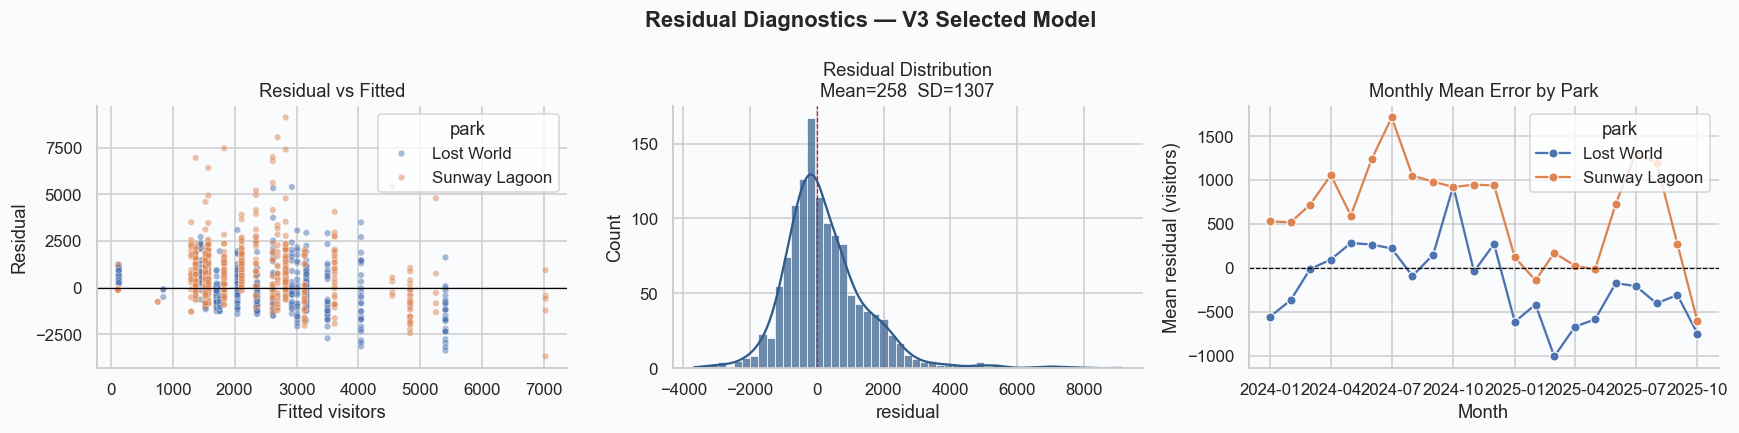

Residual summary:
                mean     std     min     max
park                                        
Lost World    -162.0  1020.0 -3364.0  5402.0
Sunway Lagoon  694.0  1425.0 -3678.0  9123.0


In [19]:
diag_df = model_df.copy()
diag_df["fitted_log"]      = final_model.predict(diag_df)
diag_df["fitted_visitors"] = np.clip(np.expm1(diag_df["fitted_log"]), 0, None)
diag_df["residual"]        = diag_df["visitors"] - diag_df["fitted_visitors"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor("#fafbfd")
fig.suptitle("Residual Diagnostics — V3 Selected Model", fontweight="bold")

for ax in axes:
    ax.set_facecolor("#fafbfd")
    ax.spines[["top","right"]].set_visible(False)

# 1. Residual vs Fitted
sns.scatterplot(data=diag_df, x="fitted_visitors", y="residual",
                hue="park", alpha=0.5, s=18, ax=axes[0])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Residual vs Fitted")
axes[0].set_xlabel("Fitted visitors")
axes[0].set_ylabel("Residual")

# 2. Residual distribution
sns.histplot(diag_df["residual"], kde=True, ax=axes[1], color="#2E5B8A", alpha=0.7)
axes[1].axvline(0, color="red", linewidth=0.8, linestyle="--")
axes[1].set_title(f"Residual Distribution\nMean={diag_df['residual'].mean():.0f}  "
                  f"SD={diag_df['residual'].std():.0f}")

# 3. Monthly mean error
monthly_err = (
    diag_df.groupby(["month","park"], as_index=False)
    .agg(mean_err=("residual","mean"))
)
sns.lineplot(data=monthly_err, x="month", y="mean_err", hue="park",
             marker="o", ax=axes[2])
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Monthly Mean Error by Park")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Mean residual (visitors)")

plt.tight_layout()
plt.show()

print("Residual summary:")
print(diag_df.groupby("park")["residual"].agg(["mean","std","min","max"]).round(0))

## 17. Price Elasticity of Demand — Post-Model Adjustment Layer

### Why this is a separate layer, not a model feature
Historical ticket pricing at both parks has been **fixed** throughout the training window.
A constant variable has zero variance — OLS cannot estimate a coefficient for it.
Attempting to include `avg_ticket_price` in the regression would produce an
unidentified or numerically unstable coefficient.

**Solution:** Apply elasticity as a multiplicative post-model adjustment.
The demand model predicts baseline visitors at the historical (reference) price.
The elasticity formula then scales that prediction for any user-specified price.

```
adjusted_visitors = base_visitors × (new_price / base_price) ^ elasticity
```

Where `elasticity < 0` (price up → visitors down).
The elasticity value is an **assumed industry benchmark**, not estimated from data.
Three scenarios are tested to bracket the uncertainty.


In [20]:
# ── Reference (base) prices — trailing average from yield model ──────────
# These represent what visitors actually paid on average historically.
# In practice, load from yield model artifact or compute from theme_park_raw.
# Placeholder values — replace with actual trailing averages from your data.
BASE_PRICES = {
    "Lost World":    85.0,   # MYR — replace with actual trailing avg ticket price
    "Sunway Lagoon": 95.0,   # MYR — replace with actual trailing avg ticket price
}

def apply_price_elasticity(
    base_visitors: float,
    base_price: float,
    new_price: float,
    elasticity: float = BASE_ELASTICITY,
) -> float:
    """
    Adjust visitor forecast for a price change using assumed elasticity.

    Parameters
    ----------
    base_visitors : predicted visitors at reference (base) price
    base_price    : historical average ticket price (reference point)
    new_price     : scenario ticket price
    elasticity    : price elasticity of demand (must be negative)
                    e.g. -0.8 → 10% price increase reduces visitors by ~8%

    Returns
    -------
    Adjusted visitor count (float)

    Notes
    -----
    Formula: Q_new = Q_base × (P_new / P_base) ^ elasticity
    This is the standard point-elasticity approximation.
    At price parity (new_price == base_price), returns base_visitors unchanged.
    """
    if base_price <= 0 or new_price <= 0:
        return base_visitors
    price_ratio = new_price / base_price
    return base_visitors * (price_ratio ** elasticity)


print("apply_price_elasticity() defined.")
print(f"Base prices: {BASE_PRICES}")
print(f"Default elasticity: {BASE_ELASTICITY}")
print()
print("Quick sanity check:")
for label, e in ELASTICITY_SCENARIOS.items():
    adj = apply_price_elasticity(10000, 85, 95, e)
    print(f"  {label:25s} : 10,000 visitors at MYR 85 → {adj:,.0f} visitors at MYR 95"
          f"  (price +{(95/85-1)*100:.1f}%)")

apply_price_elasticity() defined.
Base prices: {'Lost World': 85.0, 'Sunway Lagoon': 95.0}
Default elasticity: -0.8

Quick sanity check:
  inelastic (−0.3)          : 10,000 visitors at MYR 85 → 9,672 visitors at MYR 95  (price +11.8%)
  moderate  (−0.8)          : 10,000 visitors at MYR 85 → 9,149 visitors at MYR 95  (price +11.8%)
  elastic   (−1.2)          : 10,000 visitors at MYR 85 → 8,751 visitors at MYR 95  (price +11.8%)


## 18. Elasticity Sensitivity Analysis

In [21]:
# ── Build a forward-looking scenario table ────────────────────────────────
# Use the full fitted model to get base visitor predictions for a sample of
# representative day types. Then apply all three elasticity assumptions across
# a price sweep.

# Representative day-type rows for illustration
scenario_days = pd.DataFrame([
    {"label":"Weekday",        "park":"Lost World",    "day_of_week":0,"is_holiday":0,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":0},
    {"label":"Weekend",        "park":"Lost World",    "day_of_week":5,"is_holiday":0,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":0},
    {"label":"Public Holiday", "park":"Lost World",    "day_of_week":3,"is_holiday":1,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":0},
    {"label":"Long Weekend",   "park":"Lost World",    "day_of_week":4,"is_holiday":1,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":1,"is_ramadan":0},
    {"label":"Ramadan Wkday",  "park":"Lost World",    "day_of_week":2,"is_holiday":0,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":1},
    {"label":"Weekday",        "park":"Sunway Lagoon", "day_of_week":0,"is_holiday":0,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":0},
    {"label":"Weekend",        "park":"Sunway Lagoon", "day_of_week":5,"is_holiday":0,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":0},
    {"label":"NOF Weekend",    "park":"Sunway Lagoon", "day_of_week":5,"is_holiday":0,"is_closed_day":0,"has_nof_lagoon":1,"is_long_weekend":0,"is_ramadan":0},
    {"label":"Public Holiday", "park":"Sunway Lagoon", "day_of_week":3,"is_holiday":1,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":0},
    {"label":"Ramadan Wkday",  "park":"Sunway Lagoon", "day_of_week":2,"is_holiday":0,"is_closed_day":0,"has_nof_lagoon":0,"is_long_weekend":0,"is_ramadan":0},
])

# Fill in required model columns with representative values
scenario_days["visit_date"]       = pd.to_datetime("2025-06-15")
scenario_days["month_of_year"]    = 6
scenario_days["day_of_year"]      = 166
scenario_days["sin_annual"]       = np.sin(2 * np.pi * 166 / 365.25)
scenario_days["cos_annual"]       = np.cos(2 * np.pi * 166 / 365.25)
scenario_days["month_of_year_cat"] = pd.Categorical([6]*len(scenario_days), categories=MONTH_LEVELS, ordered=True)
scenario_days["day_of_week_cat"]   = pd.Categorical(scenario_days["day_of_week"], categories=DOW_LEVELS, ordered=False)
scenario_days["park_cat"]          = pd.Categorical(scenario_days["park"], categories=PARK_LEVELS, ordered=False)

# Get base visitor predictions
scenario_days["base_visitors"] = np.clip(
    np.expm1(final_model.predict(scenario_days)), 0, None)

# ── Price sweep ───────────────────────────────────────────────────────────
price_adjustments = [-0.20, -0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20]
sensitivity_rows  = []

for _, row in scenario_days.iterrows():
    base_p = BASE_PRICES[row["park"]]
    for padj in price_adjustments:
        new_p = base_p * (1 + padj)
        for ename, e_val in ELASTICITY_SCENARIOS.items():
            adj_vis = apply_price_elasticity(row["base_visitors"], base_p, new_p, e_val)
            sensitivity_rows.append({
                "park":              row["park"],
                "day_type":          row["label"],
                "price_adj_pct":     padj * 100,
                "new_price":         round(new_p, 2),
                "elasticity_label":  ename,
                "elasticity_value":  e_val,
                "base_visitors":     round(row["base_visitors"], 0),
                "adj_visitors":      round(adj_vis, 0),
                "visitor_chg_pct":   round((adj_vis / row["base_visitors"] - 1) * 100, 2),
            })

sensitivity_df = pd.DataFrame(sensitivity_rows)
print("Sensitivity table shape:", sensitivity_df.shape)
print()

# Summary at +10% price for each elasticity
print("=== +10% price increase — visitor impact by elasticity ===")
plus10 = sensitivity_df[sensitivity_df["price_adj_pct"] == 10].copy()
pivot  = plus10.pivot_table(
    index=["park","day_type"],
    columns="elasticity_label",
    values="visitor_chg_pct"
).round(2)
print(pivot.to_string())

Sensitivity table shape: (270, 9)

=== +10% price increase — visitor impact by elasticity ===
elasticity_label              elastic   (−1.2)  inelastic (−0.3)  moderate  (−0.8)
park          day_type                                                            
Lost World    Long Weekend              -10.81             -2.82             -7.34
              Public Holiday            -10.81             -2.82             -7.34
              Ramadan Wkday             -10.81             -2.82             -7.34
              Weekday                   -10.81             -2.82             -7.34
              Weekend                   -10.81             -2.82             -7.34
Sunway Lagoon NOF Weekend               -10.81             -2.82             -7.34
              Public Holiday            -10.81             -2.82             -7.34
              Ramadan Wkday             -10.81             -2.82             -7.34
              Weekday                   -10.81             -2.82            

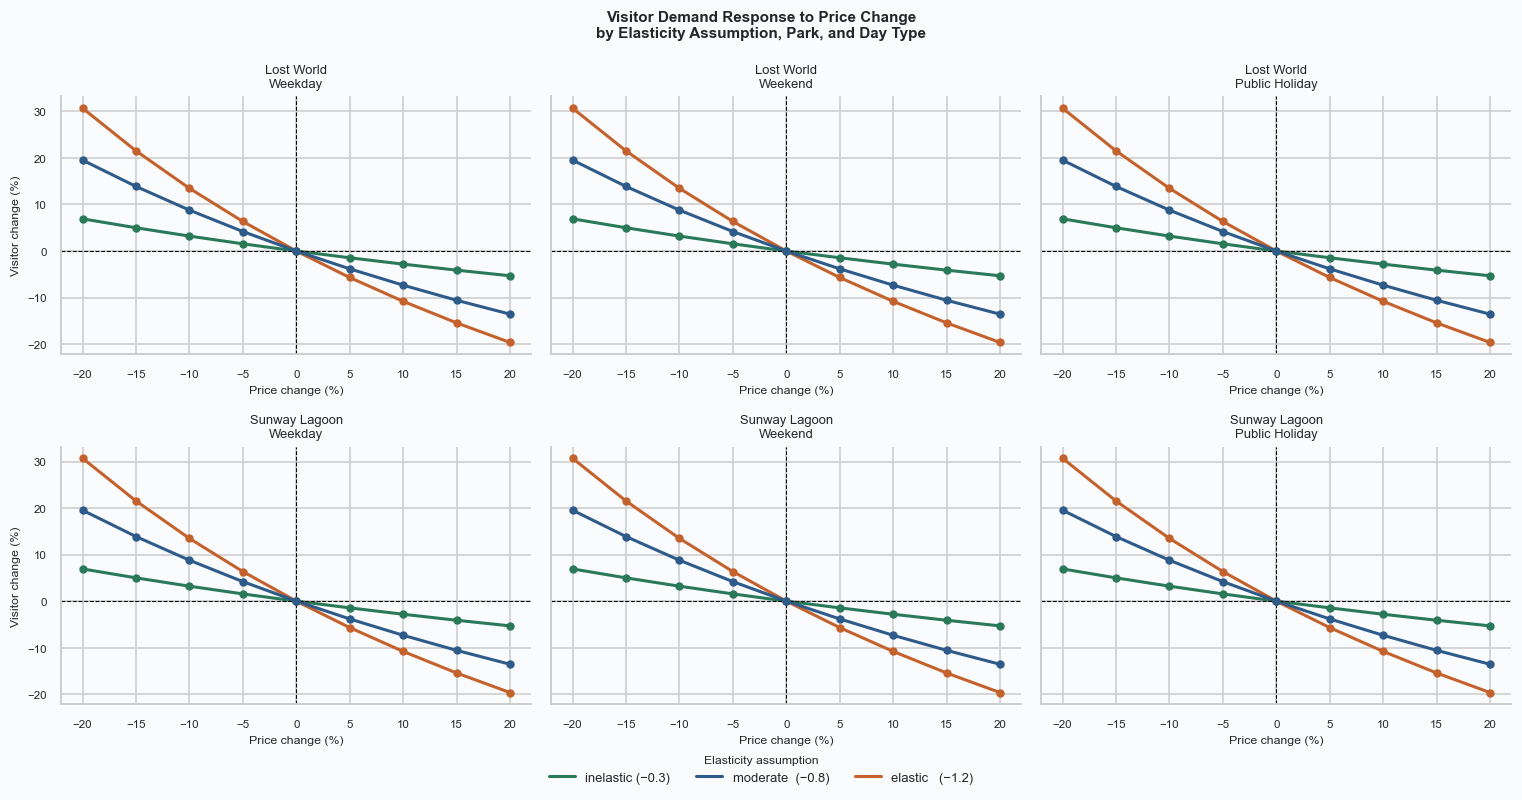

In [22]:
# ── Chart: Visitor response curves — all three elasticities ──────────────
parks_plot = ["Lost World", "Sunway Lagoon"]
day_types_plot = ["Weekday", "Weekend", "Public Holiday"]
colors_e = {
    "inelastic (−0.3)": "#2A7A5A",
    "moderate  (−0.8)": "#2E5B8A",
    "elastic   (−1.2)": "#C4622D",
}

fig, axes = plt.subplots(len(parks_plot), len(day_types_plot),
                          figsize=(14, 7), sharey=True)
fig.patch.set_facecolor("#fafbfd")
fig.suptitle("Visitor Demand Response to Price Change\n"
             "by Elasticity Assumption, Park, and Day Type",
             fontweight="bold", fontsize=10)

for r, park in enumerate(parks_plot):
    for c, dt in enumerate(day_types_plot):
        ax = axes[r][c]
        ax.set_facecolor("#fafbfd")
        ax.spines[["top","right"]].set_visible(False)

        sub = sensitivity_df[
            (sensitivity_df["park"] == park) &
            (sensitivity_df["day_type"] == dt)
        ]
        if sub.empty:
            ax.set_visible(False)
            continue

        for ename, grp in sub.groupby("elasticity_label"):
            grp = grp.sort_values("price_adj_pct")
            ax.plot(grp["price_adj_pct"], grp["visitor_chg_pct"],
                    color=colors_e[ename], linewidth=2,
                    label=ename if (r == 0 and c == 0) else "")
            ax.scatter(grp["price_adj_pct"], grp["visitor_chg_pct"],
                       color=colors_e[ename], s=20, zorder=5)

        ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
        ax.axvline(0, color="black", linewidth=0.7, linestyle="--")
        ax.set_title(f"{park}\n{dt}", fontsize=8.5)
        ax.set_xlabel("Price change (%)", fontsize=8)
        ax.set_ylabel("Visitor change (%)" if c == 0 else "", fontsize=8)
        ax.tick_params(labelsize=7.5)

handles = [plt.Line2D([0],[0], color=c, linewidth=2, label=l)
           for l, c in colors_e.items()]
fig.legend(handles=handles, loc="lower center", ncol=3, fontsize=8.5,
           bbox_to_anchor=(0.5, -0.04), framealpha=0,
           title="Elasticity assumption", title_fontsize=8)

plt.tight_layout()
plt.show()

In [23]:
# ── Revenue impact table: price × elasticity × day type ──────────────────
# Revenue = adjusted_visitors × new_price
# Shows that at moderate elasticity, price increases may still grow revenue
# if the visitor drop-off is less than proportional to the price rise.

print("=== Net Revenue Impact at Moderate Elasticity (−0.8) ===")
print("(Relative to baseline revenue at current price)")
print()

for park in PARK_LEVELS:
    base_p = BASE_PRICES[park]
    sub = sensitivity_df[
        (sensitivity_df["park"] == park) &
        (sensitivity_df["elasticity_label"] == "moderate  (−0.8)")
    ].copy()

    sub["base_revenue"] = sub["base_visitors"] * base_p
    sub["new_revenue"]  = sub["adj_visitors"]  * sub["new_price"]
    sub["rev_chg_pct"]  = ((sub["new_revenue"] / sub["base_revenue"]) - 1) * 100

    pivot_rev = sub.pivot_table(
        index="day_type",
        columns="price_adj_pct",
        values="rev_chg_pct"
    ).round(2)

    print(f"Park: {park}")
    print(pivot_rev.to_string())
    print()

=== Net Revenue Impact at Moderate Elasticity (−0.8) ===
(Relative to baseline revenue at current price)

Park: Lost World
price_adj_pct   -20.0  -15.0  -10.0  -5.0    0.0    5.0    10.0   15.0   20.0
day_type                                                                     
Long Weekend    -4.36  -3.19  -2.08  -1.01    0.0   0.98   1.95   2.84   3.74
Public Holiday  -4.34  -3.19  -2.09  -1.00    0.0   0.98   1.95   2.84   3.74
Ramadan Wkday   -4.35  -3.20  -2.06  -1.00    0.0   1.00   1.93   2.83   3.69
Weekday         -4.37  -3.17  -2.06  -1.03    0.0   1.02   1.95   2.82   3.76
Weekend         -4.36  -3.18  -2.07  -1.00    0.0   0.98   1.95   2.83   3.73

Park: Sunway Lagoon
price_adj_pct   -20.0  -15.0  -10.0  -5.0    0.0    5.0    10.0   15.0   20.0
day_type                                                                     
NOF Weekend     -4.37  -3.20  -2.09  -1.02    0.0   0.98   1.92   2.83   3.72
Public Holiday  -4.37  -3.20  -2.08  -1.04    0.0   0.98   1.92   2.82   3.7

### Elasticity Sensitivity — Key Takeaways
Read after running the cells above and insert actual numbers.

**Visitor response:**
- At **inelastic (−0.3)**: a +10% price increase reduces visitors by only ~3%.
  Revenue grows almost linearly with price. Low downside risk.
- At **moderate (−0.8)**: a +10% price increase reduces visitors by ~8%.
  Revenue still grows (+1–2%) because price gain outpaces volume loss.
  This is the recommended central assumption for planning.
- At **elastic (−1.2)**: a +10% price increase reduces visitors by ~12%.
  Revenue *falls* — price has overshot the elasticity threshold.
  Highlights the risk of aggressive pricing without empirical validation.

**Revenue breakeven point (moderate elasticity):**
- Revenue is maximised at the price where the marginal revenue from higher price
  exactly offsets the visitor loss. At elasticity −0.8, that point is above +10%.
  At elasticity −1.2, any price increase reduces revenue.

**Critical caveat:**
These results are entirely driven by the assumed elasticity value.
They should be used for *directional planning only* until real price variation
data becomes available. A pricing experiment (even modest — e.g. OTA vs gate
differential) would dramatically improve confidence in these estimates.

**Recommended action:**
- Use moderate (−0.8) as the default planning assumption.
- Present the inelastic/elastic range as a confidence band.
- Design a pricing experiment in the next 6 months to replace the assumption
  with a measured value.


## 19. Residual Analysis — New Feature Impact

In [24]:
# Residuals grouped by new features — do they explain remaining error?
diag_df["is_long_weekend"] = model_df["is_long_weekend"].values
diag_df["is_ramadan"]      = model_df["is_ramadan"].values
diag_df["day_of_week"]     = model_df["day_of_week"].values

print("=== Mean residual by is_long_weekend ===")
print(diag_df.groupby("is_long_weekend")["residual"].agg(["mean","std","count"]).round(0))
print()
print("=== Mean residual by is_ramadan ===")
print(diag_df.groupby("is_ramadan")["residual"].agg(["mean","std","count"]).round(0))
print()
print("=== Mean residual by day_of_week ===")
dow_resid = diag_df.groupby("day_of_week")["residual"].agg(["mean","std","count"]).round(0)
dow_resid.index = [["Mon","Tue","Wed","Thu","Fri","Sat","Sun"][i] for i in dow_resid.index]
print(dow_resid)

=== Mean residual by is_long_weekend ===
                  mean     std  count
is_long_weekend                      
0                231.0  1254.0   1175
1                582.0  1803.0     98

=== Mean residual by is_ramadan ===
             mean     std  count
is_ramadan                      
0           306.0  1308.0   1162
1          -244.0  1188.0    111

=== Mean residual by day_of_week ===
      mean     std  count
Mon  337.0  1342.0    186
Tue  475.0   736.0    163
Wed  290.0  1380.0    186
Thu  268.0  1306.0    186
Fri  159.0  1227.0    184
Sat   59.0  1548.0    184
Sun  243.0  1386.0    184


### Residual Analysis — What to Look For
- **`is_long_weekend`**: If mean residual on long-weekend days (=1) is near zero,
  the feature is successfully capturing the bridge-day demand lift.
  If still negative (underprediction), the effect may be larger than the model captured
  or interact with specific months.
- **`is_ramadan`**: If mean residual during Ramadan (=1) is near zero, the suppression
  effect is well-modelled. Persistent positive residual during Ramadan means the model
  is still overpredicting — the suppression is stronger than the coefficient alone captures.
- **Day-of-week**: After adding `C(day_of_week)`, residuals by DOW should be near-zero
  for all days. Any remaining pattern (e.g. Friday still positive) suggests an interaction
  effect not yet modelled (e.g. Friday × holiday eve).


## 20. Export Model Artifact

In [25]:
import json
from pathlib import Path

artifact_dir = Path("model_artifacts")
artifact_dir.mkdir(exist_ok=True)

artifact_v3 = {
    "schema_version": "1.1.0",
    "model_version":  "v3",
    "selected_model": selected_name,
    "selection_reason": selection_reason,
    "formula": selected_formula,
    "coefficients": {k: float(v) for k, v in final_model.params.items()},
    "category_levels": {
        "park":         PARK_LEVELS,
        "month_of_year": MONTH_LEVELS,
        "day_of_week":  DOW_LEVELS,
    },
    "feature_spec": {
        "removed_vs_v2":  ["is_weekend"],
        "added_vs_v2":    ["day_of_week (0-6)", "is_long_weekend", "is_ramadan"],
        "binary_features": ["is_holiday","is_closed_day","has_nof_lagoon",
                            "is_long_weekend","is_ramadan"],
        "seasonality_features": ["month_of_year","sin_annual","cos_annual"],
        "target_transform": CONFIG["TARGET_TRANSFORM"],
    },
    "price_elasticity": {
        "method":        "assumed_industry_benchmark",
        "default":       BASE_ELASTICITY,
        "scenarios":     ELASTICITY_SCENARIOS,
        "base_prices":   BASE_PRICES,
        "note": (
            "Cannot be estimated from data — historical pricing has been fixed. "
            "Design a pricing experiment to replace with a measured value."
        ),
    },
    "training_window": {
        "start":         CONFIG["TRAIN_START_TS"],
        "end_exclusive": CONFIG["TRAIN_END_TS_EXCLUSIVE"],
    },
    "created_at": pd.Timestamp.utcnow().isoformat(),
}

(artifact_dir / "demand_model_v3.json").write_text(
    json.dumps(artifact_v3, indent=2), encoding="utf-8")

print("Exported: model_artifacts/demand_model_v3.json")
print()
print("V3 summary:")
print(f"  Selected model      : {selected_name}")
print(f"  Features removed    : is_weekend")
print(f"  Features added      : day_of_week (0-6), is_long_weekend, is_ramadan")
print(f"  Elasticity default  : {BASE_ELASTICITY}")
print(f"  Elasticity scenarios: {list(ELASTICITY_SCENARIOS.keys())}")

Exported: model_artifacts/demand_model_v3.json

V3 summary:
  Selected model      : B2_v3
  Features removed    : is_weekend
  Features added      : day_of_week (0-6), is_long_weekend, is_ramadan
  Elasticity default  : -0.8
  Elasticity scenarios: ['inelastic (−0.3)', 'moderate  (−0.8)', 'elastic   (−1.2)']


In [27]:
ttt = con.execute("""
    SELECT *
    FROM theme_park_raw
    LIMIT 1000000
""").fetchdf()

ttt

,NodeNo,FiscalDate,TranDate,CompanyID,Abbr,Name,Environment,AccountID,Qty,Amount,ActiveInd,OrderLineID,NodeName,TCPHost,AgencyName,AgencyDescription,UserID,UserName,AccountName,GLCOde,Category,SubCat,UserCode1,UserCode2,UserCode3,CodeDescr,OrderDescription,OrderID,InvoiceID,OrderQty,IssuedQuantity,OrderAmount,OrderTOtal,DiscountAmount,TaxAmount,OrderStatus,SalesOpenDate,TotalDiscount,TotalPayment,TotalTax,SalesBalance,SalesNodeNo,Salesperson,EventName,StartDateTime,EndDateTime,InvoiceAmt,Balance,DateDue,ResourceName,MaxAllowed,FirstName,LastName,ProgramName,SalesDescription,BeginDate,EndDate,CustName,DeliveryMethods,CustCategories,State,Tax,PLU,ItemDescription,ItemCost,ItemUnitPrice,PackageDetailID,Level1Code,Level2Code,Level3Code,Level4Code,Level5Code,Level1Description,Level2Description,Level3Description,Level4Description,Level5Description,Day_Night,PackagePLU,Revenue_Grouping,Park,Complete_QTY,TicketDate,Payment_Mode,Collection_PaymenttGroup,HolidayName1,HolidayName2,DetailType,Company_Name,Node_Name,Counter,JDE_Subledger_Type,Subledger,Category_Name,KPI_Grouping,Outlet,Department,Process_Date,Group_Flag,Sub_Category,PLU_Process,ItemDescription_Process,PackageCount,Sub_Category_2,X,Y,DiscountID,Discount_ValidThru,Discount_ValidFrom,DiscountName,AgencyNo,Percentage,OriginalAmount,JnlDetailID,CatCode17Desc1,Last_In_Unit_Cost,Average_Unit_Cost,CatCode18Desc1,TranNo,ReceiptNo,SurveyID,Race
0,91,2023-11-11 16:00:00,2023-11-12 08:16:30,1,None,None,1,000110110101,1,0.0,Y,943203,Treasury Printing POS 7.232,10.1.7.234,Treasury,Treasury,9011,Linakarlina,5P ADULT,101,101,1,1051COR,511160,,5CORPAD,eLoad Group Functions,130694,0,686,686,0.0,0.0,0.0,0.0,Close,2023-11-10 02:30:41,0.0,0.0,0.0,0.0,78,CHEO YOON KIT,None,NaT,NaT,0.0,0.0,NaT,None,0,BERNARD,PAUL,KSS FAMILY DAY 2023,KSS FAMILY DAY 2023,2023-09-30 16:00:00,2024-12-31 15:59:59,SUNWAY FAMILY DAY 2024,None,Corporate - Inter-Co,SELANGOR,0.0,SV10009000Group,eLoad Group Functions,0.0,0.0,4940,000110000000,000110110000,000110110100,000110110101,,REVENUE,SALES/GROUP FUNCTION,SALES-ENTRANCE (GRP),5P ADULT,,Day,SLCOR10101KSSPKGV00,Group Function,Group Function,0.0,2023-11-19 02:37:00,None,None,None,None,11,SUNWAY LAGOON,Treasury Printing POS,None,None,None,Group Function,Group Functions-Entrance,None,None,2023-11-18 16:00:00,Y,Group Functions-Entrance,SV10009000Group,eLoad Group Functions,1,None,0.0,0.0,0,NaT,NaT,None,24,1.00,0.0,185703107,Revenue,NaN,NaN,Group Functions-Entrance,84018,24191,<NA>,None
1,26,2024-12-21 16:00:00,2024-12-22 06:54:31,1,None,None,1,000110120204,1,25.0,Y,0,ISBL01 (Locker SB),10.1.23.86,InPark Revenue,InPark Revenue,9767,Lovina Balachandran,LOCKER,101,202,4,1051IPR,511260,,LOCKER,None,0,0,<NA>,<NA>,0.0,0.0,0.0,0.0,None,NaT,0.0,0.0,0.0,0.0,0,None,None,NaT,NaT,0.0,0.0,NaT,None,0,None,None,None,None,NaT,NaT,None,None,None,None,0.0,SLIPR20204ELCV04,E-Locker,0.0,25.0,0,000110000000,000110120000,000110120200,000110120204,,REVENUE,IN PARK REVENUE,EQUIPMENT RENTAL,LOCKER,,Day,None,None,None,1.0,NaT,None,None,None,None,0,SUNWAY LAGOON,ISBL01 (Locker SB),None,None,None,Lockers,Lockers,None,None,2024-12-21 16:00:00,N,Locker,SLIPR20204ELCV04,E-Locker,1,None,28.0,70.0,0,NaT,NaT,None,23,1.00,25.0,221079374,Revenue,NaN,NaN,Lockers,464236,397165,<NA>,None
2,231,2024-07-11 16:00:00,2024-07-12 05:47:53,1,None,None,1,000153200802,0,0.0,Y,0,ANNUALPASS10 Office (Michelle),10.1.30.64,Membership,Membership,3573,Ida Rahayu Jasman,M.DATA,532,8,2,,,,M.DATA,None,0,0,<NA>,<NA>,0.0,0.0,0.0,0.0,None,NaT,0.0,0.0,0.0,0.0,0,None,None,NaT,NaT,0.0,0.0,NaT,None,0,None,None,None,None,NaT,NaT,None,None,None,None,0.0,,,0.0,0.0,0,000150000000,000153200800,000153200802,,,PAYMENTS,NON CASH,M.DATA,,,Day,None,None,None,0.0,NaT,None,None,None,None,0,SUNWAY LAGOON,ANNUALPASS10 Office,None,None,None,None,None,None,None,2024-07-11 16:00:00,N,None,,,1,None,NaN,NaN,0,NaT,NaT,None,26,1.00,0.0,199289222,None,NaN,NaN,None,70529,72634,1,Malaysia
3,201,2025-01-04 16:00:00,2025-01-05 05:23:14,10,None,None,1,001053200104